# Welcome to Apex Financial: The Loan Default Challenge

## The Scenario

Welcome aboard!

You have just been hired as the **Lead Machine Learning Engineer** at **Apex Financial**, a rapidly growing FinTech startup.

The company is facing a major challenge. Its current rule-based loan approval system is outdated and too lenient. As a result, loans are being approved for applicants who eventually **default**, costing investors millions of dollars.

However, rejecting too many applicants creates another problem: reliable customers may be turned away, leading to lost business opportunities.

The CEO has therefore replaced the old system and put **you in charge of building a data-driven solution**.

---

## Your Mission

Your goal is to build a Machine Learning pipeline that can accurately predict whether a new applicant will **default on their loan**.

However, this is not a textbook dataset.

You will face an important Machine Learning challenge:

> **Imbalanced Data Anomaly:** Loan defaults are relatively rare compared to successful repayments.

This imbalance can cause naive models to achieve high **Accuracy** while performing poorly at detecting actual defaults.

---

## The Roadmap

To build an effective prediction system, we will follow a **3-stage journey**:

### 1. The Baseline — Logistic Regression

We will begin with a simple **Logistic Regression** model.

The main goals are to:

* Establish a baseline model
* Evaluate its initial performance
* Understand why **Accuracy** can be misleading when the data is imbalanced

### 2. The Trap — Decision Tree

Next, we will build a **Decision Tree**.

This stage will help us:

* Understand how Decision Trees make predictions
* Observe the effects of increasing model complexity
* Identify the problem of **Overfitting**

### 3. The Ultimate Weapon — Random Forest

Finally, we will use a **Random Forest Ensemble**.

We will carefully tune its **hyperparameters** to:

* Improve predictive performance
* Handle the class imbalance more effectively
* Reduce overfitting
* Build a more reliable prediction model

#  How to Evaluate a Credit Risk Model: A Data Scientist's Guide

In the real world of finance and banking, algorithms are not judged by how close they get to 100%. They are judged by **how much money they save or lose**. 

Because our dataset is **imbalanced** (most people pay their loans, and only a small percentage default), standard evaluation metrics can be highly misleading. Here is how you should read your results like a true Credit Risk Analyst. Always focus your attention on **Class 1 (Charged Off / Defaulters)**.

### 1. The Trap: Accuracy
* **What it is:** The percentage of total correct predictions out of all predictions made.
* **What it shows:** "Overall, how often was the model right?"
* **How to analyze it:** **Do not trust it!** In a dataset where most people pay back their loans, a "dumb" model that simply approves *everyone* will get a high accuracy score. However, that model will fail to catch a single defaulter and will bankrupt the bank. A lower accuracy does not necessarily mean a worse model if it catches more bad loans.

### 2. The Core Metric: Recall for Class 1 (Sensitivity)
* **What it is:** Out of all the people who *actually* defaulted on their loans, how many did our model successfully catch?
* **What it shows:** The model's ability to prevent catastrophic financial loss.
* **How to analyze it:** This is your **most important business metric**. Every default that slips through the cracks (False Negative) means the bank loses its principal investment. Your goal is to choose a model that maximizes Recall, ensuring you identify as many high-risk borrowers as possible before giving them money.

### 3. The Trade-off: Precision for Class 1
* **What it is:** Out of all the people our model *labeled* as high-risk (Defaulters), how many were actually high-risk?
* **What it shows:** How "paranoid" or strict the model is. 
* **How to analyze it:** If Precision is low, it means the model is falsely accusing many good customers of being high-risk (False Positives) and rejecting their loans. In banking, we usually accept a lower Precision to get a higher Recall. **Rule of thumb:** It is cheaper for a bank to lose the *interest profit* from a falsely rejected good customer than to lose the *entire loan amount* to a falsely approved bad customer. 

### 4. The Heartbeat: Confusion Matrix
* **What it is:** A 2x2 grid showing exactly where the model made mistakes. 
* **What it shows:** 
  * **Top-Right (False Positives):** Good customers you wrongly rejected. 
  * **Bottom-Left (False Negatives):** Bad customers you wrongly approved.
* **How to analyze it:** Look at the bottom-left number. Your ultimate goal as a data scientist is to minimize this specific number. The best model is the one that keeps this number as small as possible while maintaining a reasonable balance elsewhere.

### 5. The Ultimate Judge: ROC-AUC Score
* **What it is:** The Area Under the Receiver Operating Characteristic Curve. 
* **What it shows:** The model's fundamental ability to separate and rank risk. It measures if the model consistently assigns higher risk probabilities to actual defaulters compared to good payers, regardless of strict or loose thresholds.
* **How to analyze it:** Use this to compare the overall "intelligence" of different models. 
  * A score near the middle (e.g., 0.5) means the model is guessing blindly. 
  * A near-perfect score means your model is cheating (Data Leakage—using future information). 
  * **Your Expectation:** You are looking for a realistic, solid score somewhere in between. A good ROC-AUC proves your model actually understands the financial patterns of risk.



# Section 1: Data Preparation and Exploratory Data Analysis (EDA)

## Introduction

Welcome to the **Loan Default Prediction** challenge!

In this real-world scenario, we are working with financial data to predict whether a borrower will **default on their loan**.

---

### Objective

Before manipulating the data, we first need to set up our environment.

In this step, we will import the fundamental Python libraries required for:

* **Data manipulation**
* **Numerical computations**
* **Data visualization**


In [1]:
# Import the fundamental library for data manipulation and analysis
import pandas as pd

# Import the fundamental package for scientific computing
import numpy as np

# Import the core visualization library
import matplotlib.pyplot as plt

# Import the statistical data visualization library based on matplotlib
import seaborn as sns

# Set a random seed for reproducibility across the notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment setup complete.")

Environment setup complete.


## Objective

Now that our environment is ready, it is time to load the **`loan_data.csv`** dataset.

A crucial first step in any Machine Learning pipeline is to understand the **structure and characteristics of the data** before performing any preprocessing or modeling.

### Tasks

In this step, you will:

1. Load the CSV file into a **Pandas DataFrame**.
2. Display the **first 5 rows** of the dataset.
3. Check the **number of rows and columns**.
4. Generate a concise summary of the dataset, including:

   * Column names
   * Data types
   * Non-null counts
5. Identify potential **missing values** at an early stage.

Complete the blanks in the code cell below to perform the initial inspection.


In [2]:
import random
import pandas as pd

# 1. Load a random sample of ~5% of the dataset
df = pd.read_csv(
    'loan.csv',
    skiprows=lambda i: i > 0 and random.random() > 0.05,
    low_memory=False
)

# 2. ULTIMATE ANTI-CHEAT: Drop Leakage, Bank Internals, and Redundant columns!
cols_to_drop = [
    # Data Leakage (Future info)
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt',
    'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',

    # Bank Internal Scoring
    'grade', 'sub_grade', 'int_rate', 'installment',

    # Redundant Columns
    'funded_amnt', 'funded_amnt_inv'
]

df = df.drop(
    columns=[col for col in cols_to_drop if col in df.columns],
    errors='ignore'
)

# 3. CHRONOLOGICAL SORTING (Out-of-Time setup)

df['issue_d'] = pd.to_datetime(
    df['issue_d'],
    format='%b-%Y',
    errors='coerce'
)

df = df.sort_values('issue_d')

df = df.drop(columns=['issue_d'], errors='ignore')

# 4. Filter and map the target variable

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['loan_status'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

print(f"Dataset Shape (After Ultimate Anti-Cheat filters): {df.shape}\n")
display(df.tail(5))

Dataset Shape (After Ultimate Anti-Cheat filters): (64992, 125)



,id,member_id,loan_amnt,term,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1476,NaN,NaN,10000,36 months,IT project manager,< 1 year,MORTGAGE,73000.0,Source Verified,0,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1306,NaN,NaN,10400,60 months,Fountain Technician Lead,10+ years,MORTGAGE,40000.0,Verified,0,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1278,NaN,NaN,2000,36 months,Lead Cook,2 years,RENT,30000.0,Source Verified,0,...,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN
1372,NaN,NaN,11775,36 months,Superintendent,4 years,MORTGAGE,144000.0,Source Verified,0,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1339,NaN,NaN,12000,36 months,NaN,NaN,MORTGAGE,70000.0,Source Verified,0,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Objective

In risk management and fraud detection tasks, the target variable is rarely **balanced**.

In this dataset, the target variable is **`loan_status`**:

* `1` → Loan default
* `0` → Fully paid loan

The goal of this step is to understand how these two classes are distributed in the dataset.

### Tasks

You will:

1. Calculate the **exact percentage** of each class in `loan_status`.
2. Display the class distribution.
3. Visualize the distribution using a **count plot**.
4. Examine the degree of **class imbalance**.

> **Why is this important?**
>
> Understanding the class distribution is essential because it will affect how we evaluate our Machine Learning models.
>
> When the target variable is highly imbalanced, **Accuracy alone can be misleading**. Therefore, we will need to consider other evaluation metrics later in the pipeline.


Class Distribution (%):
 loan_status
0    80.011386
1    19.988614
Name: proportion, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17384\1348773715.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


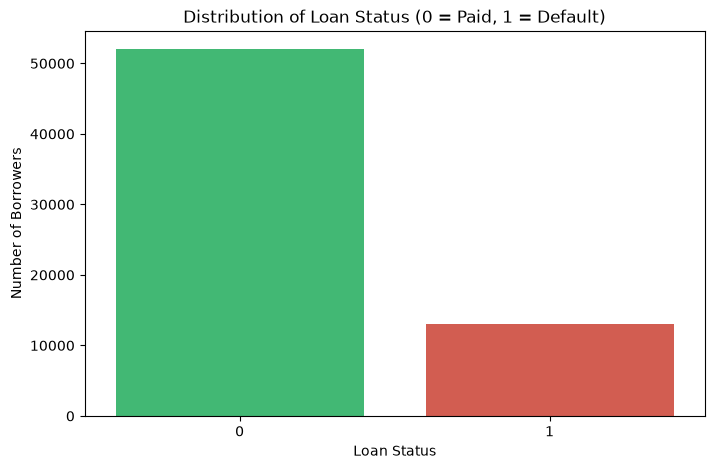

In [3]:
TARGET_COL = 'loan_status'

# Calculate the exact ratio/percentage of defaults vs. non-defaults
class_proportions = df[TARGET_COL].value_counts(normalize=True) * 100
print("Class Distribution (%):\n", class_proportions)

# Create a figure for the plot
plt.figure(figsize=(8, 5))

# Visualize the distribution using seaborn's countplot
ax = sns.countplot(
    x=TARGET_COL, 
    data=df, 
    palette=['#2ecc71', '#e74c3c']
)

# Add title and labels for clarity
plt.title('Distribution of Loan Status (0 = Paid, 1 = Default)')
plt.xlabel('Loan Status')
plt.ylabel('Number of Borrowers')

# Display the plot
plt.show()

# Section 2: Data Cleaning and Preprocessing

Real-world datasets are rarely perfect. Before feeding the data into a Machine Learning algorithm, we need to handle **missing values** properly.

Models such as **Logistic Regression** and **Random Forest** in Scikit-learn cannot directly process `NaN` values. Therefore, missing values must be identified and handled before training the models.

---

## Objective

In this step, we will identify columns containing missing values and apply an appropriate **imputation strategy** based on the type of data.

### Tasks

You will:

1. Identify the columns that contain **missing values**.
2. Fill missing **numerical values** using the **median**.
3. Fill missing **categorical values** using the **mode**.
4. Complete the imputation process by filling in the missing parts of the code.

### Imputation Strategy

| Data Type   | Method     | Reason                                                  |
| ----------- | ---------- | ------------------------------------------------------- |
| Numerical   | **Median** | Less sensitive to outliers                              |
| Categorical | **Mode**   | Replaces missing values with the most frequent category |

> **Key Idea:**
> Choosing the appropriate imputation method helps preserve the characteristics of the dataset while preventing missing values from causing problems during model training.


In [4]:
# 1. NEW STEP: Drop columns that are mostly empty (e.g., more than 50% missing values)
# This prevents errors and removes useless features for our model
threshold = len(df) * 0.5

# Drop COLUMNS that have fewer than threshold non-null values
df = df.dropna(thresh=threshold, axis=1)

# Check for total missing values in the remaining columns
missing_values = df.isnull().sum()
print("Missing values before imputation:\n", missing_values[missing_values > 0])

# Separate columns by data type for targeted imputation
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill missing numerical values with the median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with the mode (most frequent category)
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_series = df[col].mode()
        
        # Safety check in case the mode is completely empty
        if not mode_series.empty:
            df[col] = df[col].fillna(mode_series[0])
        else:
            df[col] = df[col].fillna('Unknown')

print("\nTotal missing values after imputation:", df.isnull().sum().sum())

Missing values before imputation:
 emp_title                     4019
emp_length                    3674
title                          826
dti                             16
revol_util                      32
collections_12_mths_ex_med       4
tot_coll_amt                  3342
tot_cur_bal                   3342
total_rev_hi_lim              3342
acc_open_past_24mths          2339
avg_cur_bal                   3343
bc_open_to_buy                3012
bc_util                       3046
chargeoff_within_12_mths         4
mo_sin_old_il_acct            5214
mo_sin_old_rev_tl_op          3342
mo_sin_rcnt_rev_tl_op         3342
mo_sin_rcnt_tl                3342
mort_acc                      2339
mths_since_recent_bc          2969
mths_since_recent_inq         8509
num_accts_ever_120_pd         3342
num_actv_bc_tl                3342
num_actv_rev_tl               3342
num_bc_sats                   2756
num_bc_tl                     3342
num_il_tl                     3342
num_op_rev_tl       

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17384\3355183039.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


## Objective

Machine Learning models require **numerical input**. Therefore, categorical features such as `home_ownership` and `loan_purpose` cannot be passed directly to our models.

To convert these categorical features into numerical values, we will use **One-Hot Encoding**.

### Tasks

In this step, you will:

1. Identify the **categorical features** in the dataset.
2. Apply **One-Hot Encoding** to convert categorical values into numerical features.
3. Drop the **first category** of each encoded feature.
4. Verify that the transformed dataset contains only numerical features.

---

### Why Drop the First Category?

When One-Hot Encoding is applied, keeping all categories can introduce **multicollinearity**, also known as the **Dummy Variable Trap**.

This can cause problems for models such as **Logistic Regression**.

Therefore, we will drop the first category of each encoded feature to avoid unnecessary redundancy.

> **Key Idea:**
> One-Hot Encoding converts categorical data into numerical features, while dropping the first category helps reduce multicollinearity.


In [5]:
# Check categorical columns before transformation
# Using list() instead of .tolist() makes it safe to run this cell multiple times
print("Categorical columns to encode:", list(cat_cols))

# CHALLENGE FIX: Drop categorical columns with high cardinality (too many unique values)
# If we don't do this, the encoding process will create thousands of columns and crash the RAM!
# Challenge: Find the pandas method that counts the number of UNIQUE values in a column
high_cardinality_cols = [col for col in cat_cols if df[col].nunique() > 50]

print(f"\nDropping high cardinality columns to save RAM: {high_cardinality_cols}")

# Drop them from the dataframe and update our cat_cols list
# Challenge: Use the correct method to remove these specific columns
df = df.drop(columns=high_cardinality_cols, errors='ignore')
cat_cols = [col for col in cat_cols if col not in high_cardinality_cols]

# Apply One-Hot Encoding to the dataframe
# Challenge: Use the pandas function designed to convert categorical variables into dummy/indicator variables
df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,       # Specify which columns to encode
    drop_first=True         # Prevent the "dummy variable trap"
)

# Display the new shape of the dataset to see how many new columns were added
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")

# Preview the newly created dummy columns
display(df_encoded.head(3))

Categorical columns to encode: ['term', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']

Dropping high cardinality columns to save RAM: ['emp_title', 'title', 'zip_code', 'addr_state', 'earliest_cr_line']
Original shape: (64992, 63)
Encoded shape: (64992, 87)


,loan_amnt,annual_inc,loan_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,...,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_Joint App,disbursement_method_DirectPay,debt_settlement_flag_Y
106509,2500,110000.0,0,11.33,0.0,0.0,13.0,0.0,7274,13.1,...,False,False,False,False,False,False,False,False,False,False
106507,3500,20000.0,0,1.50,0.0,0.0,17.0,0.0,1882,32.4,...,True,False,False,False,False,False,False,False,False,False
106508,5000,45000.0,0,1.12,0.0,1.0,5.0,0.0,1783,0.0,...,False,False,False,False,False,False,False,False,False,False


## Objective

Now that our data is **clean and entirely numerical**, we can prepare it for Machine Learning models.

This step consists of three important stages:

### 1. Separate Features and Target

We need to separate the input features from the target variable:

* **`X`** → Input features used to make predictions
* **`y`** → Target variable, `loan_status`

### 2. Train-Test Split

Next, we divide the dataset into **training** and **testing** sets.

Because our target variable is highly **imbalanced**, a simple random split may produce an unrepresentative test set, potentially containing very few or even no default cases.

To maintain the same class distribution in both sets, we will use **stratified sampling**.

### 3. Feature Scaling

Different features may have very different numerical ranges. This can negatively affect **linear models** and algorithms that are sensitive to feature scale.

We will therefore use **Standardization** to transform the features so that they have:

* **Mean = 0**
* **Standard deviation = 1**

### Summary

| Step                        | Purpose                            |
| --------------------------- | ---------------------------------- |
| Feature-Target Separation   | Separate `X` from `y`              |
| Stratified Train-Test Split | Preserve the class distribution    |
| Standardization             | Put features on a comparable scale |

> **Key Idea:**
> Proper data splitting and feature scaling help ensure that our models are trained and evaluated reliably.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']

# 2. Split the data (80% train, 20% test)
# Challenge: Pass the correct parameter to ensure the Train and Test sets have the same ratio of defaults
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y  # Maintain the class distribution
)

print(f"Training set defaults ratio: {y_train.mean():.4f}")
print(f"Testing set defaults ratio: {y_test.mean():.4f}")

# 3. Scale the numerical features
scaler = StandardScaler()

# Challenge: Use the correct method to learn the scaling parameters from the training data AND apply them
X_train_scaled = scaler.fit_transform(X_train)

# Challenge: Use the correct method to ONLY apply the learned scaling parameters to the test data (avoid data leakage!)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing is fully complete!")

Training set defaults ratio: 0.1999
Testing set defaults ratio: 0.1999

Data preprocessing is fully complete!


# Section 3: Baseline Model — Logistic Regression

Before moving to more complex Machine Learning algorithms, it is good practice to establish a **baseline model** using a simple and interpretable algorithm.

For this task, we will start with **Logistic Regression**, which is commonly used for binary classification problems such as predicting whether a loan will default.

---

## Objective

In this step, you will:

1. Import the **Logistic Regression** class.
2. Instantiate the model with appropriate parameters.
3. Train the model using the **scaled training data**.
4. Make predictions on the **test set**.

### Important Consideration

Our dataset has a significant **class imbalance**, with default cases being much less frequent than non-default cases.

Therefore, the model should account for this imbalance during training. Pay close attention to the model parameters and consider using an appropriate **class weighting strategy**.

> **Key Idea:**
> Since our main goal is to detect loan defaults, simply treating both classes equally may cause the model to pay too little attention to the minority class.


In [7]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE
)

# Train (fit) the model using the scaled training features and the training target
log_reg.fit(X_train_scaled, y_train)

# Generate predictions using the scaled test features
y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression model trained and predictions generated successfully.")

Logistic Regression model trained and predictions generated successfully.


## Objective

Evaluating a Machine Learning model correctly is just as important as training it.

In this step, we will evaluate the performance of our **Logistic Regression baseline model** using several complementary evaluation metrics.

### Tasks

You will:

1. Import the necessary evaluation metrics from **Scikit-learn**.
2. Calculate the overall **Accuracy** of the model.
3. Display the **Confusion Matrix**.
4. Print the **Classification Report**.

### Analytical Challenge

After calculating these metrics, carefully examine the results.

Pay particular attention to the model's performance on:

* **Class `0`** → Fully paid loans
* **Class `1`** → Loan defaults

> **Key Question:**
> Does the overall **Accuracy** accurately represent the model's ability to detect loan defaults?
>
> Compare the results for class `0` and class `1` in the **Confusion Matrix** and **Classification Report** to determine whether the model performs equally well on both classes.


In [8]:
# Import the required evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate and print the overall accuracy score
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {acc_log:.4f}\n")

# Generate the confusion matrix
# Hint: The standard order for these functions is (y_true, y_pred)
cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:\n", cm_log, "\n")

# Generate and print the full classification report
report_log = classification_report(y_test, y_pred_log)
print("Classification Report:\n", report_log)

Accuracy: 0.6954

Confusion Matrix:
 [[7408 2993]
 [ 966 1632]] 

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.71      0.79     10401
           1       0.35      0.63      0.45      2598

    accuracy                           0.70     12999
   macro avg       0.62      0.67      0.62     12999
weighted avg       0.78      0.70      0.72     12999



# Section 4: Decision Trees and the Overfitting Trap

We will now implement a **Decision Tree Classifier**.

Decision Trees are highly interpretable and can capture **non-linear relationships** between features. However, when a tree is allowed to grow without restrictions, it can become overly complex and memorize the training data.

This can lead to **Overfitting**.

---

## Objective

In this step, you will:

1. Import the **Decision Tree Classifier** from Scikit-learn.
2. Instantiate a completely **unconstrained** Decision Tree.
3. Use only `random_state` to ensure **reproducibility**.
4. Train the model using the **scaled training data**.
5. Generate predictions for both:

   * **Training set**
   * **Testing set**

### Analytical Focus

After training the model, compare its predictions on the training and testing sets.

> **Key Idea:**
> An unconstrained Decision Tree can grow until it captures very specific patterns in the training data. Comparing training and testing performance will help us identify the **Overfitting Trap**.


In [9]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate an unconstrained Decision Tree
dt_unconstrained = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Fit the model on the training data
dt_unconstrained.fit(X_train_scaled, y_train)

# Generate predictions for BOTH train and test sets
# We need both to analyze the model's learning behavior
y_train_pred_dt = dt_unconstrained.predict(X_train_scaled)
y_test_pred_dt = dt_unconstrained.predict(X_test_scaled)

print("Unconstrained Decision Tree trained successfully.")

Unconstrained Decision Tree trained successfully.


## Objective

To understand the behavior of our **unconstrained Decision Tree**, we need to evaluate its performance on both the training and testing datasets.

### Tasks

In this step, you will:

1. Calculate the **Accuracy** on the training set.
2. Calculate the **Accuracy** on the testing set.
3. Print the **Classification Report** for the test set.
4. Compare the results with the **baseline Logistic Regression** model.

### Analytical Challenge

Carefully compare the training and testing accuracy.

> **Key Questions:**
>
> * Is there a significant difference between the training and testing accuracy?
> * What does this difference tell us about the model's behavior?
> * How does the Decision Tree perform on the **minority class (1)** compared with the baseline Logistic Regression?
>
> Use the **Classification Report** to compare metrics such as **Precision, Recall, and F1-score** for class `1`.


In [10]:
# Calculate and print accuracy for the training set
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
print(f"Training Accuracy: {train_acc_dt:.4f}")

# Calculate and print accuracy for the testing set
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)
print(f"Testing Accuracy: {test_acc_dt:.4f}\n")

# Print the classification report for the test set
report_dt = classification_report(y_test, y_test_pred_dt)
print("Unconstrained Decision Tree - Test Classification Report:\n", report_dt)

Training Accuracy: 1.0000
Testing Accuracy: 0.7265

Unconstrained Decision Tree - Test Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83     10401
           1       0.33      0.37      0.35      2598

    accuracy                           0.73     12999
   macro avg       0.58      0.59      0.59     12999
weighted avg       0.74      0.73      0.73     12999



## Objective

Now it is time to improve our **Decision Tree** and address the overfitting problem observed in the previous step.

We will use **`GridSearchCV`** to systematically search through different combinations of hyperparameters and find a better-constrained model.

### Challenges

In this step, you will:

1. Define a **`param_grid`** that explores different ways to control the growth and complexity of the Decision Tree.
2. Consider the **class imbalance** when selecting the hyperparameters and model configuration.
3. Choose an appropriate **`scoring`** metric for `GridSearchCV`.
4. Find the **best combination of hyperparameters** using cross-validation.
5. Retrieve the **best estimator**.
6. Evaluate the optimized model on the **test set**.

### Analytical Challenge

The dataset is highly imbalanced, so **Accuracy should not be the primary metric** for hyperparameter tuning.

> **Key Question:**
> Which evaluation metric would better reflect the model's ability to identify the minority class (`1`)?
>
> After obtaining the optimized model, compare its test-set performance with the **unconstrained Decision Tree** and the **Logistic Regression baseline**.


In [11]:
from sklearn.model_selection import GridSearchCV

# Challenge: Select the appropriate hyperparameters to tune. 
# Think about what controls the depth, node splitting rules, and class distribution!
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'class_weight': [None, 'balanced']
}

# Initialize a new base model
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Configure GridSearchCV
# Challenge: Set the appropriate scoring metric for an imbalanced dataset
grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    scoring='recall', 
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Execute the grid search on the training data
grid_search_dt.fit(X_train_scaled, y_train)

# Output the best parameters found by GridSearchCV
print("\nBest Hyperparameters Found:")
print(grid_search_dt.best_params_)

# Retrieve the best model
best_dt_model = grid_search_dt.best_estimator_

# Evaluate the optimized model on the test set
y_pred_best_dt = best_dt_model.predict(X_test_scaled)

print(
    "\nOptimized Decision Tree - Classification Report:\n",
    classification_report(y_test, y_pred_best_dt)
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Hyperparameters Found:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 20}

Optimized Decision Tree - Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.70      0.77     10401
           1       0.32      0.58      0.41      2598

    accuracy                           0.67     12999
   macro avg       0.59      0.64      0.59     12999
weighted avg       0.76      0.67      0.70     12999



# Section 5: Random Forest and the Hyperparameter Battle

A single **Decision Tree** can easily overfit the training data.

To address this problem, we can use an **ensemble learning** method called **Random Forest**. Instead of relying on a single tree, a Random Forest builds multiple decision trees and combines their predictions to produce a final result.

---

## Objective

In this step, we will first evaluate a **Random Forest with its default settings** to establish a baseline for the ensemble model.

### Tasks

You will:

1. Import the **Random Forest Classifier** from Scikit-learn.
2. Instantiate the model using the provided `RANDOM_STATE`.
3. Train the Random Forest on the **scaled training data**.
4. Generate predictions for the **test set**.
5. Evaluate the model's performance on the test set.

### Analytical Focus

This first model uses the **default hyperparameters**. Its purpose is to give us a reference point before we begin hyperparameter tuning.

> **Key Idea:**
> Random Forest reduces the reliance on a single Decision Tree by combining predictions from multiple trees. In the next steps, we will investigate whether tuning its hyperparameters can further improve its performance.


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the baseline Random Forest model
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)

# Fit the model to the training data
rf_baseline.fit(X_train_scaled, y_train)

# Generate predictions on the test set
y_pred_rf_base = rf_baseline.predict(X_test_scaled)

# Print the classification report for the baseline Random Forest
print("Baseline Random Forest - Classification Report:\n")
print(classification_report(y_test, y_pred_rf_base))

Baseline Random Forest - Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.99      0.90     10401
           1       0.87      0.15      0.26      2598

    accuracy                           0.83     12999
   macro avg       0.85      0.57      0.58     12999
weighted avg       0.83      0.83      0.77     12999



## Objective

The baseline **Random Forest** provides a useful starting point, but we can potentially improve its ability to detect the **minority class (Defaults)** through hyperparameter tuning.

In this step, we will use **`GridSearchCV`** to find a suitable combination of Random Forest hyperparameters.

### Challenges

You will:

1. Define a **`param_grid`** that explores:

   * The **number of trees** in the forest
   * The **maximum depth** of each tree
   * A parameter that gives greater importance to the **minority class**
2. Select an appropriate **`scoring`** metric for the Grid Search.
3. Use **cross-validation** to identify the best combination of hyperparameters.
4. Keep the parameter grid **reasonable** to avoid unnecessarily long computation times.

### Important Consideration

Random Forest already requires more computation than a single Decision Tree. When combined with `GridSearchCV`, every hyperparameter combination must be evaluated across multiple cross-validation folds.

Therefore, avoid creating an excessively large search space.

> **Key Idea:**
> The goal is not simply to maximize overall Accuracy. We want the tuned Random Forest to pay sufficient attention to **loan defaults**, while keeping the model's overall performance reliable.


In [13]:
from sklearn import set_config
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Turn off the interactive HTML/drawer display for scikit-learn models
set_config(display='text')

# Initialize a new Random Forest base model
rf_tuner = RandomForestClassifier(random_state=RANDOM_STATE)

# A balanced parameter grid: 3 * 3 * 1 * 2 = 18 combinations
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'class_weight': ['balanced'],
    'min_samples_leaf': [2, 4]
}

# Configure GridSearchCV with cv=4 (18 combinations * 4 folds = 72 fits)
grid_search_rf = GridSearchCV(
    estimator=rf_tuner,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=4,
    n_jobs=-1,
    verbose=2
)

print("Starting the Balanced Grid Search... (Will test 18 combinations x 4 folds = 72 fits)")

# Execute the grid search on the training data
grid_search_rf.fit(X_train_scaled, y_train)

Starting the Balanced Grid Search... (Will test 18 combinations x 4 folds = 72 fits)
Fitting 4 folds for each of 18 candidates, totalling 72 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [10, 15, 20], 'min_samples_leaf': [2, 4],
                         'n_estimators': [50, 100, 150]},
             scoring='roc_auc', verbose=2)

## Objective

The Grid Search is complete. It is now time to evaluate the **optimized Random Forest** and compare it with the models developed earlier.

### Tasks

In this final evaluation step, you will:

1. Extract the **best hyperparameters** found by `GridSearchCV`.
2. Retrieve the **best Random Forest model**.
3. Generate predictions on the **test set**.
4. Evaluate the optimized model using appropriate classification metrics.
5. Compare its performance with:

   * **Logistic Regression**
   * **Single Decision Tree**
   * **Optimized Random Forest**

### Analytical Challenge

Focus on the performance of the **minority class (1)**, rather than relying only on overall Accuracy.

> **Key Questions:**
>
> * How did hyperparameter tuning affect the Random Forest's performance?
> * Does the optimized model detect more default cases effectively?
> * How does its performance compare with the Logistic Regression baseline and the single Decision Tree?
>
> Use the **Classification Report** and other relevant metrics to make a data-driven comparison of the three models.


In [14]:
# Output the best parameters found by GridSearchCV
print("Ultimate Hyperparameters Found:")
print(grid_search_rf.best_params_)

# Retrieve the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

# Generate final predictions on the test set
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

# Print the final classification report
print("\nOptimized Random Forest - Final Classification Report:\n")
print(classification_report(y_test, y_pred_best_rf))

# Calculate the final evaluation metric (e.g., F1-score for class 1 or ROC-AUC)
# Optional Challenge: Try to calculate and print the ROC-AUC score
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    best_rf_model.predict_proba(X_test_scaled)[:, 1]
)

print(f"\nFinal ROC-AUC Score: {roc_auc:.4f}")

Ultimate Hyperparameters Found:
{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 150}

Optimized Random Forest - Final Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.89      0.87     10401
           1       0.47      0.41      0.44      2598

    accuracy                           0.79     12999
   macro avg       0.67      0.65      0.66     12999
weighted avg       0.78      0.79      0.79     12999


Final ROC-AUC Score: 0.7372


# Section 6: Feature Importance

One of the key advantages of tree-based models such as **Random Forest** is their ability to provide information about **feature importance**.

Feature importance helps us understand which features contributed most to the model's predictions.

In the context of loan default prediction, this allows us to investigate:

> **What factors are most influential in predicting loan defaults?**

---

## Objective

In this step, you will extract and visualize the feature importances from the **optimized Random Forest model**.

### Tasks

You will:

1. Extract the **feature importances** from the optimized Random Forest.
2. Create a **Pandas DataFrame** that maps each importance value to its corresponding feature name.
3. Sort the features by importance in **descending order**.
4. Select the **top 10 most important features**.
5. Visualize these features using a **horizontal bar plot**.

### Analytical Focus

After creating the visualization, examine the top-ranked features and consider their potential relationship with loan defaults.

> **Key Idea:**
> Feature importance provides a way to interpret which variables the Random Forest relied on most when making predictions. However, high feature importance does **not necessarily imply a causal relationship** with loan defaults.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17384\3850910155.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


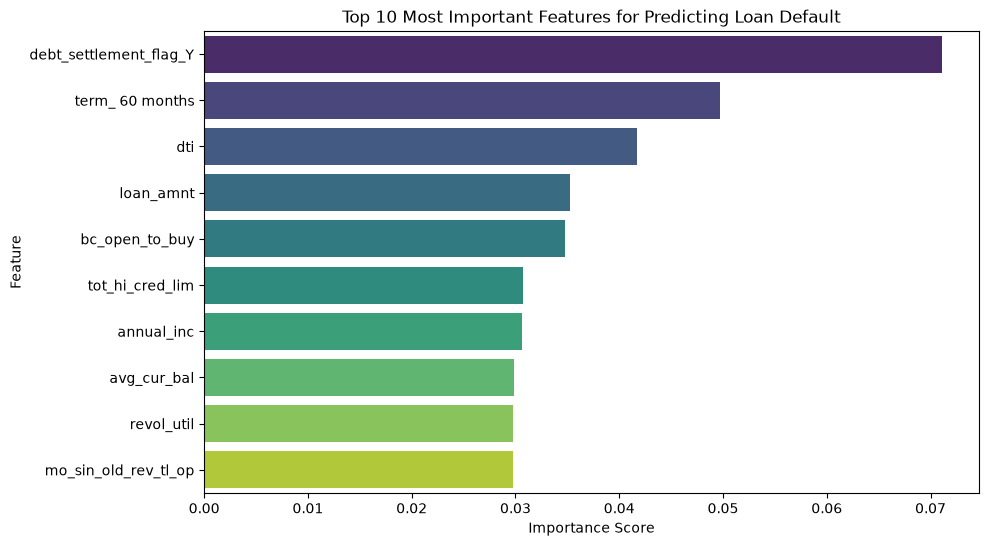

In [15]:
# Extract the feature importances from the best Random Forest model
# Challenge: Find the correct attribute of the fitted Random Forest model
importances = best_rf_model.feature_importances_

# Get the names of the features from the training data
feature_names = X.columns

# Create a DataFrame to hold feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Visualize the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10),
    palette='viridis'
)

plt.title('Top 10 Most Important Features for Predicting Loan Default')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Answer this question after completing the task.
 **The Student Challenge:** Compare the outputs of your Logistic Regression, unconstrained Decision Tree, and Random Forest models. Which model achieved the highest Accuracy? Which one achieved the highest Recall for Class 1? **Which model would you recommend to the bank's CEO, and why?**

In [16]:
from sklearn.metrics import roc_auc_score

log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
roc_auc_log = roc_auc_score(y_test, log_proba)

print(f"Logistic Regression ROC-AUC: {roc_auc_log:.4f}")

Logistic Regression ROC-AUC: 0.7375


In [17]:
dt_proba = best_dt_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_dt = roc_auc_score(y_test, dt_proba)

print(f"Decision Tree ROC-AUC: {roc_auc_dt:.4f}")

Decision Tree ROC-AUC: 0.6843
